
#**KCCV 2026 Workshop/Tutorial**
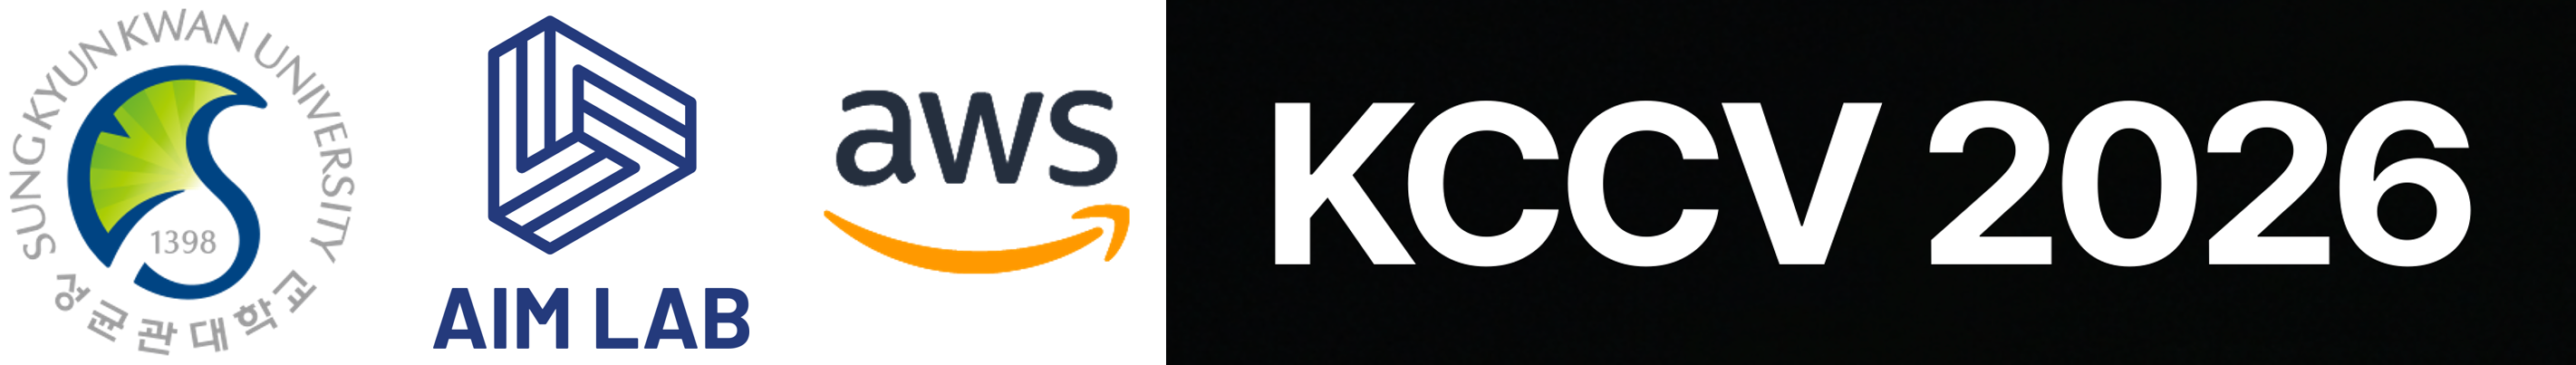


## **ZOO-Prune**: Token Pruning via Zeroth-Order Gradient Estimation in Vision-Language Models (CVPR 2026)

Youngeun Kim*, Youjia Zhang*, Huiling Liu, Aecheon Jung, Sunwoo Lee, Sungeun Hong📧

[[Project Page]](https://aim-skku.github.io/ZOO-Prune/) [[Paper]](https://openaccess.thecvf.com/content/CVPR2026/html/Kim_ZOO-Prune_Training-Free_Token_Pruning_via_Zeroth-Order_Gradient_Estimation_in_Vision-Language_CVPR_2026_paper.html) [[Code]](https://github.com/AIM-SKKU/ZOO-Prune/tree/main)

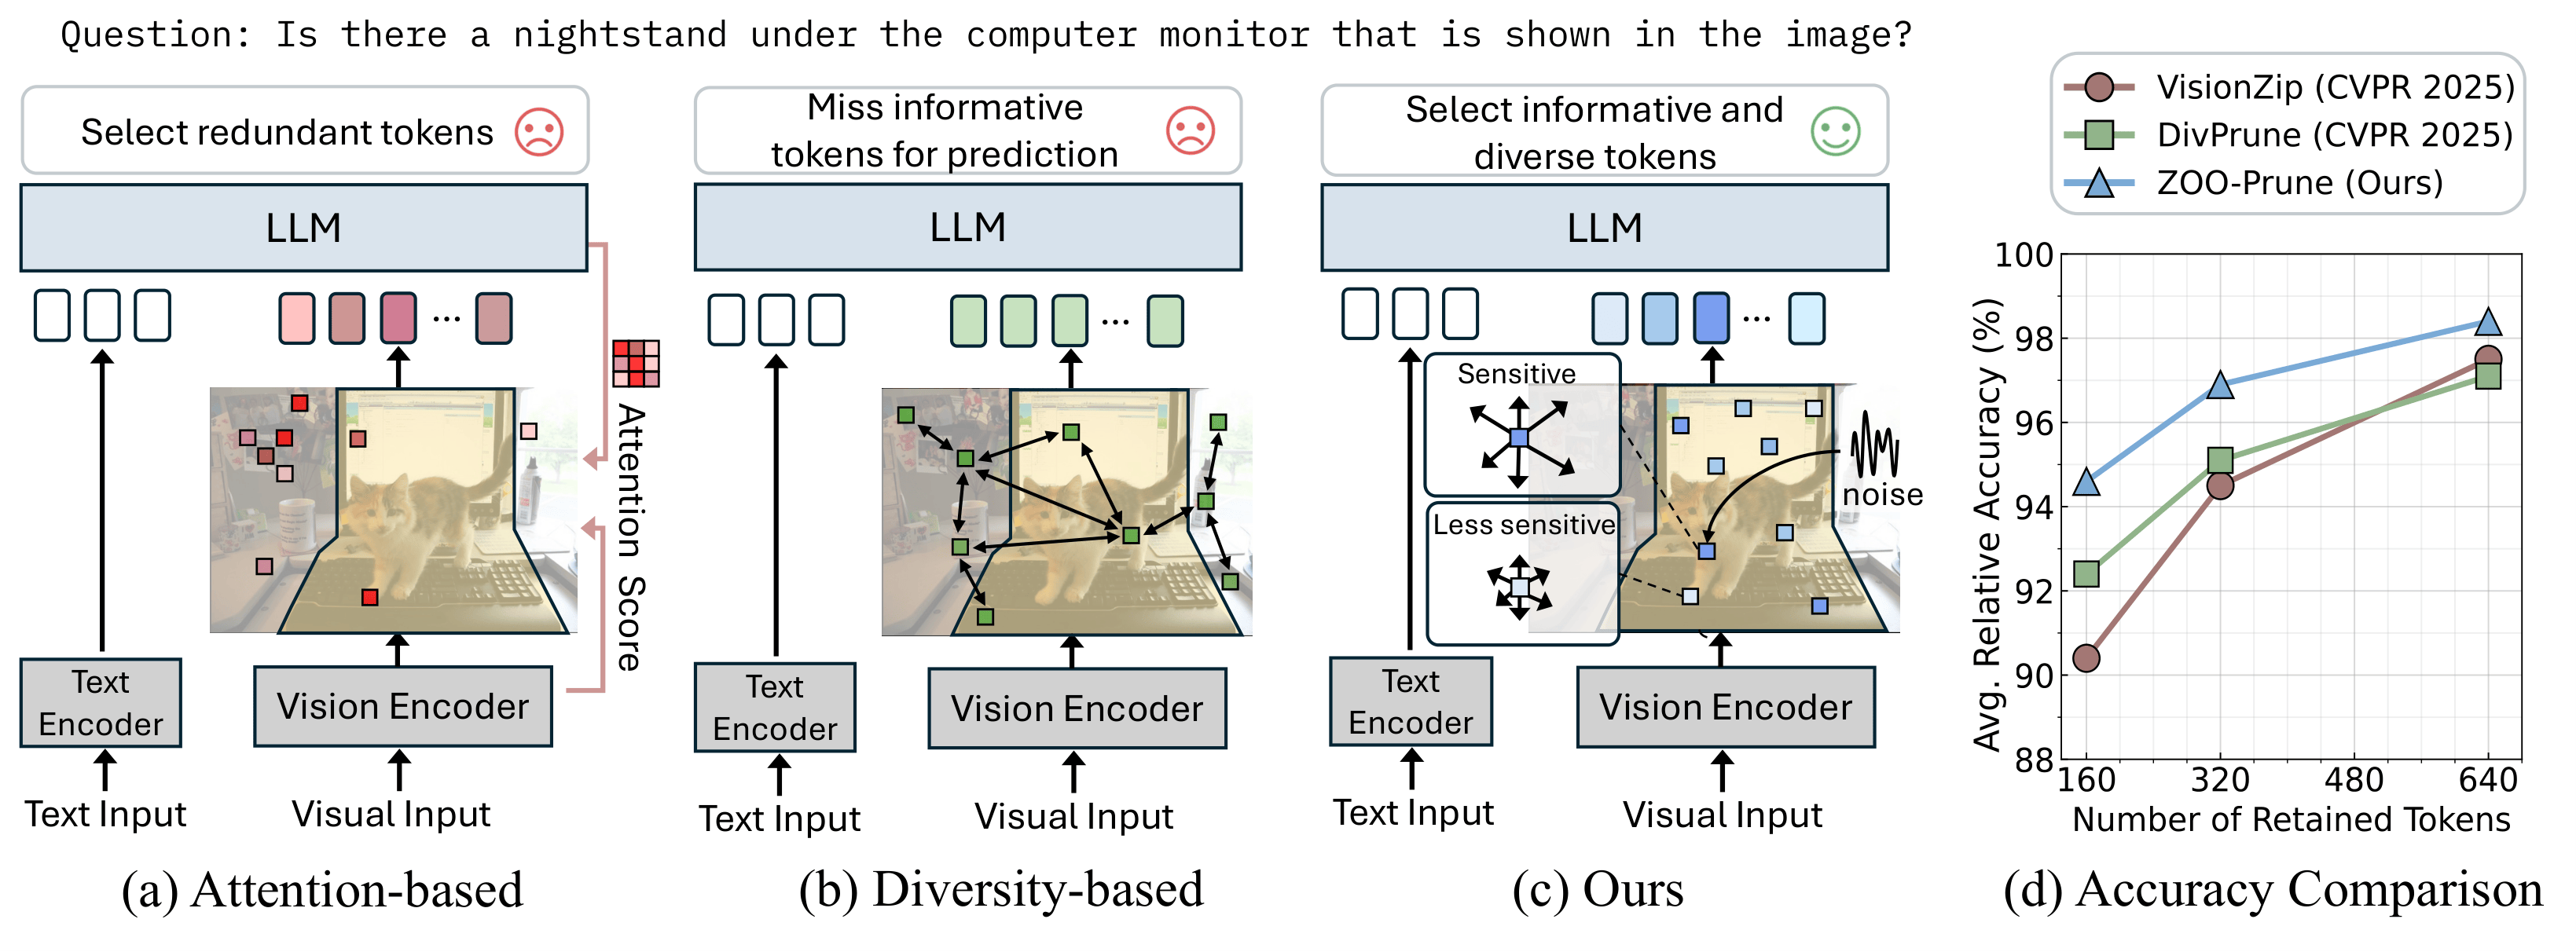




### What we will do in this code tutorial

1. Environment setup

2. A simplified view of a Vision-Language Model, like LLaVA
* Inspect the visual tokens and multimodal projector
* Analysis of redundant visual tokens
* Computational analysis


3. Visual Token pruning
* Reproduce ZOO-Prune's forward-only *zeroth-order sensitivity estimation*
* Reproduce our *Sensitivity-Aware Diverse Selection* (SADS)
* Compare the different pruning strategies

4. More qualitative and quantitative *results*
* Vary VLM baselines
* Sensitivity vs. Attention vs. Diversity

5. Further analysis of the sensitivity proxy
* Revisiting Token Sensitivity Proxy: Projector vs. Encoder
* Perturbation stability

6. Further Inference Efficiency Analysis
* ZOO-Prune FLOPs, prefill time, and end-to-end latency


# 1. Environment setup

This section prepares a **minimal, reproducible Colab environment** for the tutorial.

Instead of installing the entire benchmark stack, we:

1. clone the official ZOO-Prune repository;
2. install the LLaVA dependencies required by the demo;
3. register the repository's modified LLaVA package in editable mode;
4. fix the random seed so that perturbation-based results are reproducible.


In [ ]:
# ------------------------------------------------------------
# 1) Clone the official implementation.
# ------------------------------------------------------------
import os, sys, subprocess, random, time
from pathlib import Path

REPO_DIR = Path("/content/ZOO-Prune")
if not REPO_DIR.exists():
    subprocess.run(["git", "clone", "-q", "https://github.com/AIM-SKKU/ZOO-Prune.git", str(REPO_DIR)], check=True)


# ------------------------------------------------------------
# 2) Install only the packages required by the tutorial path.
#    The full lmms-eval benchmark stack is intentionally omitted.
# ------------------------------------------------------------
packages = [
    "transformers==4.37.2", "accelerate==0.34.2",
    "bitsandbytes==0.48.2", "sentencepiece==0.1.99",
    "shortuuid==1.0.13", "einops==0.6.1",
    "einops-exts==0.0.4", "timm==0.6.13"
]
subprocess.run([sys.executable, "-m", "pip", "install", "-q", *packages], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir", "--force-reinstall", "--no-deps", "bitsandbytes==0.48.2"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(REPO_DIR / "LLaVA"), "--no-deps"], check=True)

# ------------------------------------------------------------
# 3) register the repository's modified LLaVA package in editable mode;
# Editable installation means the imported functions are executed directly from the cloned repository.
# ------------------------------------------------------------

os.chdir(REPO_DIR)
sys.path.insert(0, str(REPO_DIR))
sys.path.insert(0, str(REPO_DIR / "LLaVA"))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

# ------------------------------------------------------------
# 4) Fix all random seeds.
# ------------------------------------------------------------

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print("Repository:", REPO_DIR)
print("PyTorch:", torch.__version__, "| CUDA:", torch.cuda.is_available())

Repository: /content/ZOO-Prune
PyTorch: 2.11.0+cu128 | CUDA: True


# 2. A simplified view of a Vision-Language Model

##　What is the Vision-Language Model (VLM) ?

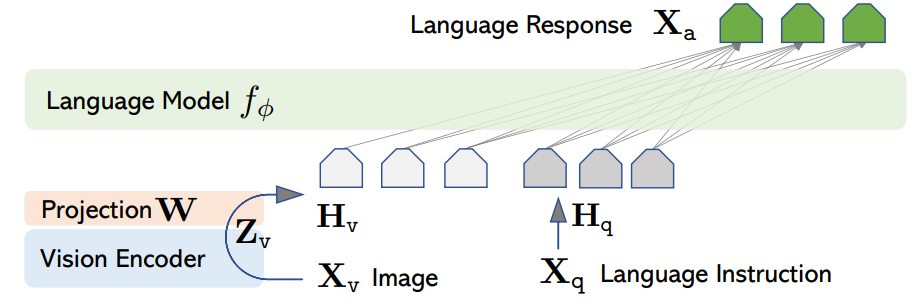
A Vision-Language Model (VLM) extends a language model so that it can jointly process visual inputs and natural-language instructions.

In a typical VLM such as LLaVA:
* **Vision Encoder:** converts the image into visual features.
* **MM Projector:** maps the visual features into the language-model embedding space.
* **Language Model:** combines the projected visual tokens with text tokens to generate a response.


## Before introducing pruning, we first identify ***what is being pruned***.

For LLaVA-1.5, an input image is processed through three main stages:

$$
\text{Image}
\;\overset{\text{Vision Encoder}}{\longrightarrow}\;
X \in \mathbb{R}^{N_v \times d_v}
\;\overset{\text{MM Projector}}{\longrightarrow}\;
Z \in \mathbb{R}^{N_v \times d}
\;\overset{\text{LLM}}{\longrightarrow}\;
\text{Answer}
$$
- $N_v$: number of visual tokens;
- $d_v$: vision-encoder feature dimension;
- $d$: LLM hidden dimension;
- $X$: pre-projector visual tokens;
- $Z=M(X)$: projected visual tokens inserted into the language-model sequence.

ZOO-Prune does **not** modify the vision encoder or retrain the model.
- It estimates token sensitivity at the vision–language interface and shortens the visual sequence before expensive LLM inference.

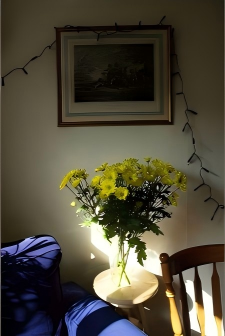

Question: What’s hanging above the flowers?

The context passed to LLaVA:
What’s hanging above the flowers?
"Answer the question using a single word or phrase."


In [ ]:
# ------------------------------------------------------------
# One fixed image/question pair is used throughout the tutorial,
# so changes in the visual mask can be compared consistently.
# ------------------------------------------------------------
# Example image and question for the LLaVA model to answer.
IMAGE_PATH = str(REPO_DIR / "images" / "test_image.png")  #@param {type:"string"}
QUESTION = "What’s hanging above the flowers?"  #@param {type:"string"}
POST_PROMPT = "\"Answer the question using a single word or phrase.\"" # @param {"type":"string"}

def build_context_prompt(question):
    """Exact text transformation used by lmms_eval/tasks/pope/utils.py."""
    return f"{question.strip()}\n"+POST_PROMPT

EVAL_CONTEXT = build_context_prompt(QUESTION)
image = Image.open(IMAGE_PATH).convert("RGB")
display(image)
print("Question:", QUESTION)
print("\nThe context passed to LLaVA:\n" + EVAL_CONTEXT)

## 2.1 Load LLaVA-1.5 and isolate the visual pathway

The tutorial supports two execution modes:

- **Full model mode:** loads the complete LLaVA-1.5-7B model and serves as a reference for how ZOO-Prune is used in a real deployment and end-to-end inference setting.
- **Lightweight tutorial mode:** loads only the vision tower and the officially trained multimodal projector. This is sufficient to explain and execute the core ZOO-Prune procedure while requiring substantially less GPU memory, making it suitable for demonstration on a Google Colab T4 GPU.

Both modes use the same official vision encoder and multimodal projector. Therefore, the visual features and projector responses used in this tutorial are produced by the original model components rather than by synthetic or approximate substitutes.

In [ ]:

os.environ["BASELINE"] = "FULL"
MODEL_PATH = "liuhaotian/llava-v1.5-7b"
Run_Full_Model=False


if Run_Full_Model:
  ## load the LLaVA model and process the image
  from llava.model.builder import load_pretrained_model
  from llava.mm_utils import get_model_name_from_path, process_images
  from llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN
  from llava.conversation import conv_templates
  from llava.mm_utils import tokenizer_image_token

  """
  tokenizer: LLaVA language models' tokenizer, tokenizer in Vicuna-7B for llava-v1.5-7b
  model: Full LLaVA
  image_processor：LLaVA's image processor
  context_len: max length of the context
  """
  tokenizer, model, image_processor, context_len = load_pretrained_model(
      model_path=MODEL_PATH,
      model_base=None,
      model_name=get_model_name_from_path(MODEL_PATH),
      device_map="auto",
      torch_dtype=torch.float16,
  )
  model.eval()

  processed_image = process_images([image], image_processor, model.config)
  if isinstance(processed_image, list):
      processed_image = [x.to(model.device, dtype=torch.float16) for x in processed_image]
  else:
      processed_image = processed_image.to(model.device, dtype=torch.float16)
  # print("Loaded:", MODEL_PATH)


  vision_tower = model.get_vision_tower()
  core_model = model.get_model()
  processed_image = processed_image if torch.is_tensor(processed_image) else processed_image[0]

  # 1) Execute the LLaVA-1.5 vision path.
  with torch.no_grad():
      vision_token_batch = vision_tower(processed_image)
      projected_token_batch = core_model.mm_projector(vision_token_batch)
  pre_projector_tokens=vision_token_batch[0]
  projected_tokens=projected_token_batch[0]


  # 2) Reproduce the conversation prompt construction (lmms_eval/models/llava.py).
  def build_lmms_eval_prompt(context, num_images=1, conv_template="vicuna_v1"):
      if DEFAULT_IMAGE_TOKEN not in context:
          image_tokens = " ".join([DEFAULT_IMAGE_TOKEN] * num_images) # add <image> placeholder
          question = image_tokens + "\n" + context
      else:
          question = context
      conv = conv_templates[conv_template].copy()
      conv.append_message(conv.roles[0], question)#3 "vicuna_v1"->conv.roles == ("USER", "ASSISTANT")
      conv.append_message(conv.roles[1], None)
      return conv.get_prompt()

  trace_prompt = build_lmms_eval_prompt(EVAL_CONTEXT)
  # converts the prompt into token IDs
  trace_input_ids = tokenizer_image_token(
      trace_prompt, tokenizer, IMAGE_TOKEN_INDEX, return_tensors="pt"
  ).unsqueeze(0).to(model.device)


  # 3) Let LLaVA replace <image> with the projected visual embeddings.
  with torch.no_grad():
      _, _, _, _, full_inputs_embeds, _ = model.prepare_inputs_labels_for_multimodal(
          trace_input_ids, None, None, None, None,
          processed_image, image_sizes=[image.size]
      )

  # Convert the prompt into token IDs.
  #
  # The <image> placeholder is first represented by one IMAGE_TOKEN_INDEX.
  # No visual embeddings are inserted at this stage.
  #
  # Later, prepare_inputs_labels_for_multimodal() replaces this placeholder
  # with the full projected visual-token sequence:
  #
  #     <image>
  #        ↓ tokenizer_image_token()
  #     one IMAGE_TOKEN_INDEX
  #        ↓ prepare_inputs_labels_for_multimodal()
  #     576 projected visual embeddings

  # 4) Run the decoder-only LLM autoregressively to generate the answer.
  with torch.no_grad():
      output_ids = model.generate(
          input_ids=trace_input_ids,
          images=processed_image,
          image_sizes=[image.size],
          do_sample=False,
          max_new_tokens=32,
          use_cache=True,
      )

  answer = tokenizer.decode(
      output_ids[0],
      skip_special_tokens=True,
  ).strip()

  print("Generated answer:", answer)

else:
  # Lightweight tutorial mode

  from huggingface_hub import hf_hub_download
  from transformers import AutoConfig
  from llava.mm_utils import process_images, expand2square
  from llava.model.multimodal_encoder.builder import build_vision_tower
  from llava.model.multimodal_projector.builder import build_vision_projector
  from types import SimpleNamespace

  DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

  config = AutoConfig.from_pretrained(MODEL_PATH,)
  config.image_aspect_ratio = "pad"
  vision_tower = build_vision_tower(config, delay_load=False)
  vision_tower = vision_tower.to(DEVICE, dtype=torch.float16).eval()
  vision_tower.requires_grad_(False)
  image_processor = vision_tower.image_processor

  projector = build_vision_projector(config)
  projector_path = hf_hub_download(
      repo_id=MODEL_PATH, filename="mm_projector.bin",)
  raw_state = torch.load(projector_path, map_location="cpu", weights_only=True)
  prefix = "model.mm_projector."
  projector_state = {
      (key[len(prefix):] if key.startswith(prefix) else key): value
      for key, value in raw_state.items()
  }
  incompatible = projector.load_state_dict(projector_state, strict=True)
  assert not incompatible.missing_keys and not incompatible.unexpected_keys
  projector = projector.to(DEVICE, dtype=torch.float16).eval()
  projector.requires_grad_(False)
  core_model = SimpleNamespace(mm_projector=projector)


  processed_image = process_images(
      [image],image_processor,config,
      ).to(DEVICE,dtype=torch.float16,)


  print("Loaded real vision tower:", config.mm_vision_tower)
  print("Loaded official trained projector:", projector_path)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

mm_projector.bin:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Loaded real vision tower: openai/clip-vit-large-patch14-336
Loaded official trained projector: /root/.cache/huggingface/hub/models--liuhaotian--llava-v1.5-7b/snapshots/4481d270cc22fd5c4d1bb5df129622006ccd9234/mm_projector.bin


## 2.2 One image, 576 visual tokens

LLaVA-1.5 resizes and normalizes the image to $336\times336$, then divides it into a $24\times24$ patch grid:

$$
N_v = 24\times24 = 576.
$$

So, the vision tower maps the image to:

$$
[1,3,336,336]
\rightarrow
[1,576,1024],
$$
and the multimodal projector aligns every token with the *Vicuna language space*:

$$
[1,576,1024]
\rightarrow
[1,576,4096].
$$

The projector changes the **feature dimension**, but it does not reduce the **sequence length**. Consequently, all 576 visual tokens enter every LLM layer unless an explicit compression method is applied.

In [ ]:
import os
import torch
import pandas as pd
import numpy as np
from PIL import Image
import textwrap


# ---------------------------------------------------------
# Execute the exact LLaVA visual pathway.
#
# vision tower's input is processed_image：[batch_size, 3, 336, 336]
# vision tower: [1, 3, 336, 336] -> [1, 576, 1024]
# MM projector: [1, 576, 1024] -> [1, 576, 4096]
#
# Notice: the projector aligns dimensions but keeps all 576 tokens.
# ---------------------------------------------------------
with torch.inference_mode():
    vision_token_batch = vision_tower(processed_image)
    projected_token_batch = core_model.mm_projector(vision_token_batch)
pre_projector_tokens=vision_token_batch[0]
projected_tokens=projected_token_batch[0]

# Read token-grid metadata from the actual vision tower rather than hard-coding 24 × 24
vision_token_num = vision_token_batch.shape[1]
grid_side = vision_tower.num_patches_per_side

assert vision_token_num == vision_tower.num_patches
assert grid_side**2 == vision_token_num


# ---------------------------------------------------------
# showing the feature shapes.
# ---------------------------------------------------------
pipeline_rows = [
    ("Input image", f"{image.width} × {image.height}"),
    ("CLIPImageProcessor", tuple(processed_image.shape)),
    ("Vision tower, CLS removed", tuple(vision_token_batch.shape)),
    ("MM projector", tuple(projected_token_batch.shape)),
    ("Visual tokens before Projector", vision_token_num),
    ("Visual tokens after Projector", projected_token_batch.shape[1]),
]

display(pd.DataFrame(
        pipeline_rows,
        columns=["Executed stage", "Observed output"],)
)

,Executed stage,Observed output
0,Input image,225 × 336
1,CLIPImageProcessor,"(1, 3, 336, 336)"
2,"Vision tower, CLS removed","(1, 576, 1024)"
3,MM projector,"(1, 576, 4096)"
4,Visual tokens before Projector,576
5,Visual tokens after Projector,576


### Visualizing the tokenization process

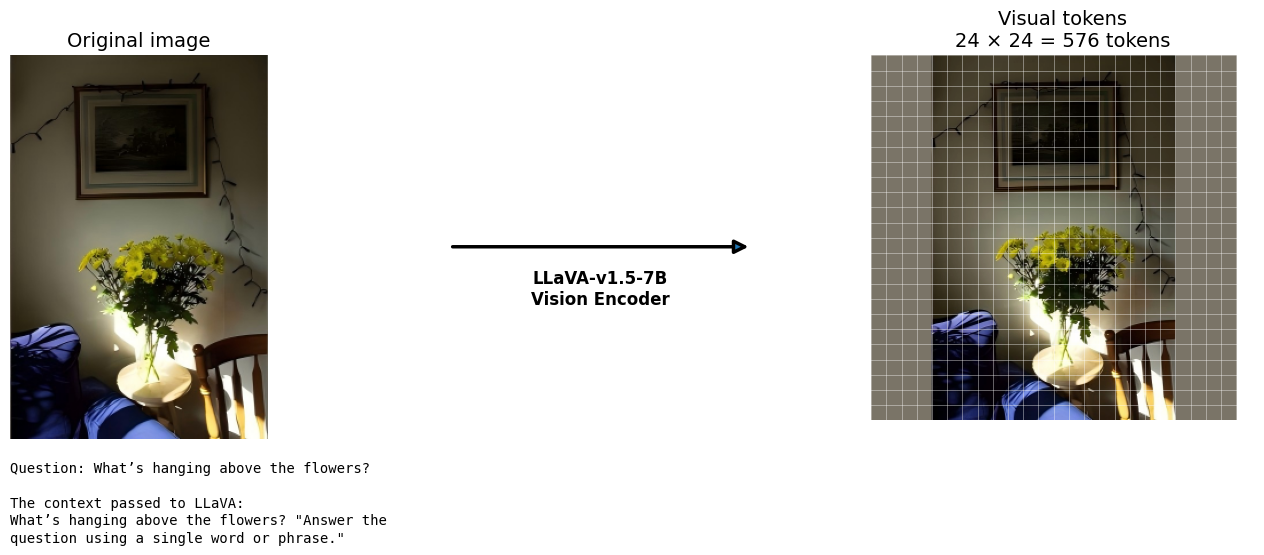

In [ ]:
def show_visual_token_pipeline(original_image,processed_image,question,eval_context,grid_size,):
    fig, (ax_left, ax_arrow, ax_right) = plt.subplots(1,3,figsize=(16, 6),gridspec_kw={"width_ratios": [1, 0.55, 1],"wspace": 0.08,},)
    # 1. Left: original input and the exact text context.
    ax_left.imshow(original_image)
    ax_left.set_title("Original image", fontsize=14)
    ax_left.axis("off")

    prompt_text = (
        f"Question: {textwrap.fill(question, width=50)}\n\n"
        f"The context passed to LLaVA:\n"
        f"{textwrap.fill(eval_context, width=50)}"
    )

    ax_left.text(0,-0.06,prompt_text,transform=ax_left.transAxes,ha="left",va="top",fontsize=10,fontfamily="monospace",linespacing=1.3,)

    # 2. Middle: the vision encoder converts pixels to patch features.
    ax_arrow.annotate("",xy=(1, 0.5),xytext=(0, 0.5),arrowprops={"arrowstyle": "-|>","linewidth": 2.5,"mutation_scale": 20,},)
    ax_arrow.text(0.5,0.44,"LLaVA-v1.5-7B\nVision Encoder",ha="center",va="top",fontsize=12,fontweight="semibold",)
    ax_arrow.set_xlim(0, 1)
    ax_arrow.set_ylim(0, 1)
    ax_arrow.axis("off")

    # 3. Right: each grid cell corresponds to one visual token.
    ax_right.imshow(presenter_image)
    height, width = np.asarray(processed_image).shape[:2]
    for x in np.linspace(0, width, grid_size + 1):
        ax_right.axvline(x,color="white",alpha=0.45,linewidth=0.6,)
    for y in np.linspace(0, height, grid_size + 1):
        ax_right.axhline(y,color="white",alpha=0.45,linewidth=0.6,)
    ax_right.set_title(
        f"Visual tokens\n"
        f"{grid_size} × {grid_size} = {grid_size**2} tokens",
        fontsize=14,
    )
    ax_right.axis("off")
    plt.subplots_adjust(left=0.04,right=0.96,top=0.90,bottom=0.26,)
    plt.show()


def visualize_processed_image(processed_image,image_processor,):
    """Reverse CLIP normalization and return a displayable PIL image."""
    pixels = processed_image[0].detach().float().cpu()

    # Reverse CLIP normalization.
    mean = torch.tensor(image_processor.image_mean,dtype=pixels.dtype,).view(3, 1, 1)
    std = torch.tensor(image_processor.image_std,dtype=pixels.dtype,).view(3, 1, 1)
    pixels = (pixels * std + mean).clamp(0, 1)

    # Convert [3, H, W] tensor to a PIL image.
    presenter_image = Image.fromarray((pixels.permute(1, 2, 0).numpy() * 255).astype(np.uint8))

    # display(presenter_image)
    return presenter_image

presenter_image = visualize_processed_image(
    processed_image,
    image_processor,
)

show_visual_token_pipeline(
    original_image=image,
    processed_image=presenter_image,
    question=QUESTION,
    eval_context=EVAL_CONTEXT,
    grid_size=grid_side,
)

The grid above is a spatial interpretation of the 576 visual tokens. Each cell corresponds to one patch-level representation produced by the vision encoder.

Two observations motivate token pruning:

1. neighboring patches often describe highly similar background or texture content;
2. the language model still pays the computational cost for every token, even when many patches contribute little to the answer.

The goal is therefore **not simply to remove patches**, but to retain a small subset that preserves influential and complementary visual info.



## 2.3 Why redundant visual tokens are computationally expensive

Let:

- $N_t$ be the number of text tokens, including the system prompt,
  question, and instruction;
- $N_v$ be the number of visual tokens;
- $n=N_t+N_v$ be the complete prefill sequence length;
- $L$ be the number of Transformer layers;
- $d$ be the hidden dimension;
- $d_{\mathrm{ff}}$ be the feed-forward intermediate dimension.

Ignoring small normalization and activation terms, the `prefill FLOPs` of a decoder-only Transformer are approximately

$$
\boxed{
FLOP_{\mathrm{prefill}}(n)
=
L\left(
4nd^2
+
2n^2d
+
2ndd_{\mathrm{ff}}
\right)
}
$$

where:

- $4nd^2$: query, key, value, and output projections;
- $2n^2d$: attention score computation and value aggregation;
- $2ndd_{\mathrm{ff}}$: the two feed-forward linear transformations.

The important point is that visual tokens increase both:

- the **linear projection/MLP terms**, and
- the **quadratic self-attention term** $2n^2d$.

After pruning to $k$ visual tokens, the sequence becomes
$
\hat{n}=N_t+k,
$

and the prefill saving is

$$
\boxed{
\Delta F_{\mathrm{prefill}}
=
F_{\mathrm{prefill}}(N_t+N_v)
-
F_{\mathrm{prefill}}(N_t+k)
}
$$

Thus, token redundancy is not merely a storage issue: every redundant token is repeatedly processed by all \(L\) language-model layers.

In [ ]:
# ------------------------------------------------------------
# Approximate the LLM prefill cost before and after pruning.
# ------------------------------------------------------------
NUM_LAYERS = 32
HIDDEN_DIM = projected_tokens.shape[-1]      # 4096
FFN_DIM = 11008
TEXT_TOKENS = 62

def transformer_prefill_flops(
    sequence_length,
    num_layers=NUM_LAYERS,
    hidden_dim=HIDDEN_DIM,
    ffn_dim=FFN_DIM,
):
    n, L, d, d_ff = (
        sequence_length,
        num_layers,
        hidden_dim,
        ffn_dim,
    )
    projection = 4 * n * d**2
    attention = 2 * n**2 * d
    feed_forward = 2 * n * d * d_ff
    return L * (
        projection
        + attention
        + feed_forward
    )

full_sequence = TEXT_TOKENS + vision_token_num
full_flops = transformer_prefill_flops(full_sequence)

rows = []
for visual_budget in [576, 192, 128, 64]:
    sequence_length = TEXT_TOKENS + visual_budget
    flops = transformer_prefill_flops(sequence_length)
    rows.append({
        "Visual tokens": visual_budget,
        "Total prefill tokens": sequence_length,
        "Approx. prefill TFLOPs": flops / 1e12,
        "Relative to full": flops / full_flops,
        "Approx. saving": 1 - flops / full_flops,
    })

display(pd.DataFrame(rows).round(4))

,Visual tokens,Total prefill tokens,Approx. prefill TFLOPs,Relative to full,Approx. saving
0,576,638,3.3179,1.0000,0.0000
1,192,254,1.2953,0.3904,0.6096
2,128,190,0.9658,0.2911,0.7089
3,64,126,0.6383,0.1924,0.8076


# 3. Visual-token pruning→ZOO-Prune

### ZOO-Prune estimates token sensitivity at the projection layer and combines it with diversity-aware selection.

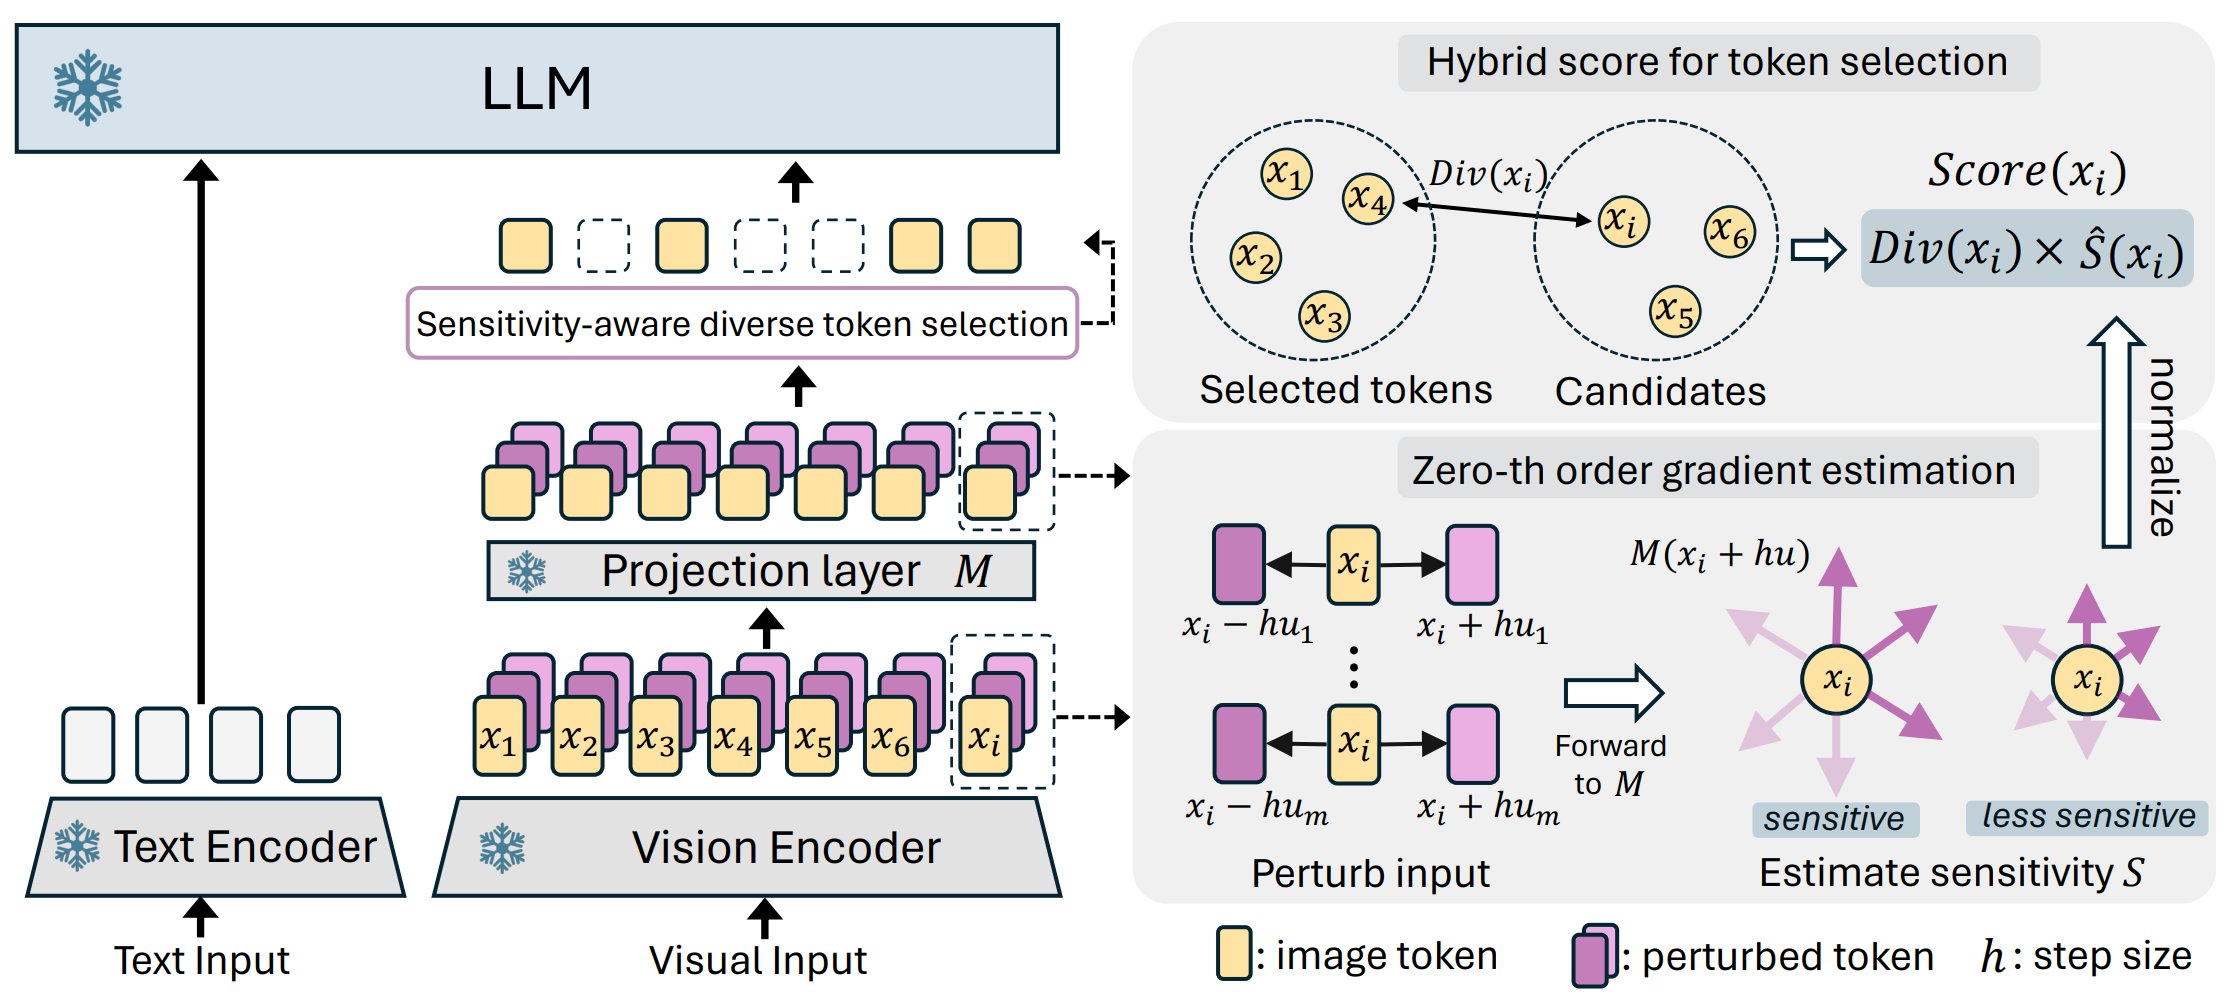

ZOO-Prune performs training-free visual token pruning in two stages. It first estimates the sensitivity of each visual token through zeroth-order perturbations at the lightweight projection layer, and then selects a compact subset of tokens by combining sensitivity with diversity.

1. **Zeroth-order sensitivity estimation**. Token importance is measured by the output change caused by small random perturbations, without requiring backpropagation.
2. **Projection-layer proxy**. Sensitivity is computed at the projection layer, which provides an efficient and effective proxy for visual token importance.
2. **Sensitivity-aware diversity selection**. The final token subset preserves both informative and complementary visual content under aggressive pruning.





## Pruning ratio and hyperparameters


We now reduce the 576-token visual sequence under a fixed token budget.

Typical LLaVA-1.5 budgets used by ZOO-Prune are:

| Retained tokens $k$| Retention ratio | Pruning ratio |
|---:|---:|---:|
| 192 | 33.3% | 66.7% |
| 128 | 22.2% | 77.8% |
| 64 | 11.1% | 88.9% |




In [ ]:
## Hyperparameters

MODEL_PATH = "liuhaotian/llava-v1.5-7b"  #@param {type:"string"}
TOKEN_BUDGET = 64      #@param {type:"integer"}
NUM_DIRECTIONS = 64    #@param {type:"integer"}
STEP_SIZE = 0.01       #@param {type:"number"}

## 3.1 The core: forward-only zeroth-order token sensitivity

A useful pruning score should answer:

> If this visual token changes slightly, how strongly does the vision–language representation respond?

For visual token $x_i$, ZOO-Prune samples $m$ normalized random directions $u_j$ and uses a symmetric finite difference. We define the token
sensitivity of token i as the average response magnitude:

$$S(i)=\frac{1}{m}\sum_{j=1}^{m}\left\|\frac{M(x_i+h u_j)-M(x_i-h u_j)}{2h}\right\|_2.$$

There is no loss and no backward pass. All token/direction pairs are batched into **two projector forwards**.

Here:

- $M(\cdot)$: the multimodal projector;
- $h$: a small perturbation magnitude;
- $u_j \sim \mathcal{N}(0, I)$: a randomly sampled perturbation direction, normalized to unit norm;
- a larger $S(i)$: token $i$ has a stronger influence on the projected representation.

### Why this is efficient

There is no task loss and no backward pass. All token–direction pairs are flattened into one batch, requiring only:

- one projector forward for $+h$;
- one projector forward for $-h$.

The perturbed features are used only as **probes**; they are not passed to the LLM as the final visual representation.

In [ ]:
@torch.no_grad()
def compute_zoo_sensitivity(features, projector, m=64, h=0.01, seed=42):
    """
    Compute forward-only ZO sensitivity.

    Args:
        features: [N_v, d_v] pre-projector visual tokens.
        projector: multimodal projector M.
        m: number of random perturbation directions.
        h: symmetric finite-difference step.
        seed: controls the sampled directions.

    Returns:
        sensitivity_scores: [N_v].
    """
    N_v, d_v = features.shape # N_v visual token with d_v dim

    # KEY STEP 1: sample m unit direction perturbations.
    # One direction u_j is shared by all N_v tokens in that query.

    generator = torch.Generator(device=features.device)
    generator.manual_seed(seed)

    u = torch.randn(m,d_v,generator=generator,device=features.device,dtype=features.dtype,)


    # u = torch.randn(m, d_v, device=features.device, dtype=features.dtype) # noise for m dim
    u = u / (u.norm(dim=-1, keepdim=True) + 1e-12) # normalize
    u_expanded = u.unsqueeze(1).expand(-1, N_v, -1)  # Applying the same u to all visual tokens


    # KEY STEP 2: construct symmetric +h and -h probes.
    perturb_plus = features.unsqueeze(0) + h * u_expanded
    perturb_minus = features.unsqueeze(0) - h * u_expanded

    # KEY STEP 3: flatten every token–direction pair into one batch.
    # projector input flatten → [1, m*N_v, d_v]
    perturb_plus_flat = perturb_plus.reshape(m * N_v, d_v).unsqueeze(0).half()
    perturb_minus_flat = perturb_minus.reshape(m * N_v, d_v).unsqueeze(0).half()

    # process by the projector
    with torch.no_grad():
      proj_plus = projector(perturb_plus_flat)
      proj_minus = projector(perturb_minus_flat)

    # reshape back [direction, token, language dimension].
    d_l = proj_plus.shape[-1]
    proj_plus = proj_plus.view(m, N_v, d_l)
    proj_minus = proj_minus.view(m, N_v, d_l)

    # KEY STEP 4: sensitivity to vision token
    # two-sided directional response and direction average.
    delta_proj = proj_plus - proj_minus    # [m, N_v, d_l]
    coeff = delta_proj.norm(dim=-1) / (2*h)  # [m, N_v]
    sensitivity_scores = coeff.mean(dim=0)    # [N_v]
    return sensitivity_scores


sensitivity = compute_zoo_sensitivity(
    pre_projector_tokens, core_model.mm_projector,
    m=NUM_DIRECTIONS, h=STEP_SIZE, seed=SEED
).float().cpu()

print("Defined compute_zoo_sensitivity(): two batched forward queries, no backward.")
print("Sensitivity size:", sensitivity.shape)

Defined compute_zoo_sensitivity(): two batched forward queries, no backward.
Sensitivity size: torch.Size([576])


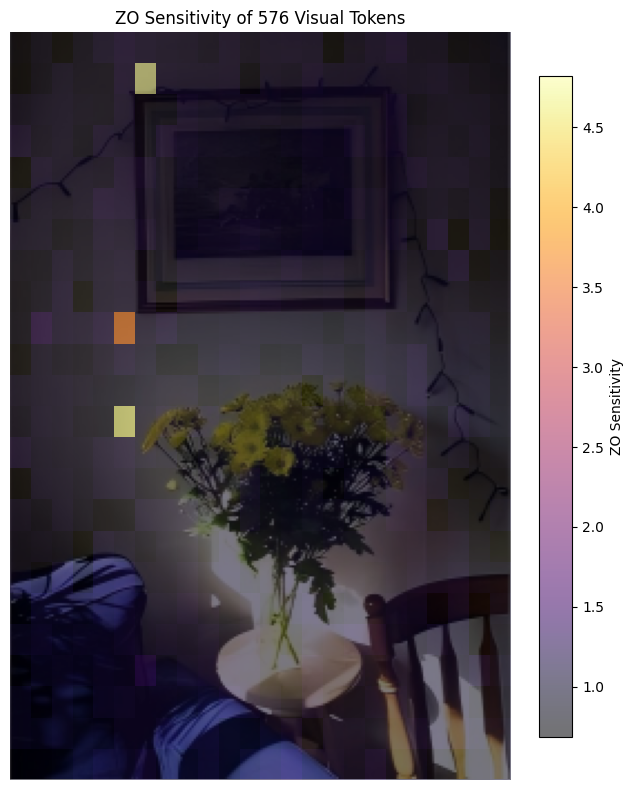

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def show_zoo_sensitivity(original_image,scores,grid_size,):
    """Overlay all ZO sensitivity values on the original image."""

    scores = scores.detach().float().cpu()
    assert scores.numel() == grid_size**2

    # Restore the token sequence to its 2-D patch layout.
    sensitivity_map = scores.reshape(grid_size,grid_size,).numpy()

    width, height = original_image.size
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(original_image)

    overlay = ax.imshow(
        sensitivity_map,
        cmap="inferno",
        alpha=0.55,
        interpolation="nearest",
        extent=(0, width, height, 0),
    )

    ax.set_title(f"ZO Sensitivity of {scores.numel()} Visual Tokens")
    ax.axis("off")

    colorbar = fig.colorbar(overlay,ax=ax,fraction=0.046,pad=0.04,)
    colorbar.set_label("ZO Sensitivity")
    plt.tight_layout()
    plt.show()



show_zoo_sensitivity(
    original_image=image,
    scores=sensitivity,
    grid_size=grid_side,
)

## 3.2 Sensitivity-aware diverse selection (SADS)

Selecting only the top-k sensitivity scores can repeatedly choose visually or semantically similar tokens.
SADS therefore combines:

- **influence:** normalized ZO sensitivity $\widehat S(i)$;
- **complementarity:** distance from the already selected set $P$.

For projected visual features $Z_i$, define cosine distance:
$
D(i,j)=1-\cos(Z_i,Z_j).
$





At each greedy step, SADS selects:
*   Sensitivity finds influential tokens;
*   diversity prevents us from repeatedly selecting similar content.

$$\operatorname{Score}(i)=\widehat S(i)\left(1-\max_{j\in P}\cos(Z_i,Z_j)\right).$$

- P: the set of already selected tokens.
- cos(·, ·): cosine similarity
The first token is the most sensitive.

Every later token must be both sensitive and different from the selected set.

In [ ]:
@torch.no_grad()
def select_sads(features, sensitivity, k):
    """
    Sensitivity-Aware Diverse Selection (SADS)
    Combines DivPrune's greedy diversity with ZOO-based sensitivity.

    Args:
        visual_feature_vectors: [N_v, d] - projected image tokens
        importance_scores: [N_v] - ZOO-based sensitivity (var of similarity)
        k: int - number of tokens to select

    Returns:
        selected_indices: [k]
    """

    N_v = features.shape[0]
    device = features.device


    # KEY STEP 1: pairwise cosine distance. 1 - cosine similarity
    # A large value means two projected tokens are dissimilar.
    with torch.no_grad():
        # [N_v, N_v]
        cosine_sim = F.cosine_similarity(
            features.unsqueeze(1),
            features.unsqueeze(0),
            dim=-1
        )
        dist_matrix = 1.0 - cosine_sim  # [N_v, N_v]

    # KEY STEP 2: Normalize sensitivity to [0, 1]
    if sensitivity.max() > sensitivity.min():
        sens_weight = (sensitivity - sensitivity.min()) / (sensitivity.max() - sensitivity.min() + 1e-8)
    else:
        sens_weight = torch.ones_like(sensitivity)

    # KEY STEP 3: greedy sensitivity-weighted max–min selection.
    selected = torch.empty(k, dtype=torch.long, device=device)

    for i in range(k):
      if i == 0:
          # Start from the most influential token.
          scores = sens_weight
      else:
          # diversity = distance to the nearest selected token.
          selected_dists = torch.index_select(dist_matrix, 0, selected[:i])  # [i, N_v]
          min_dist_to_selected = selected_dists.min(dim=0).values  # [N_v]

          # A candidate must be both influential and complementary.
          # Hybrid Score: distance × sensitivity
          scores = min_dist_to_selected * sens_weight  # higher score：more important and higher min_dis

      mask = torch.ones(N_v, dtype=torch.bool, device=device)
      if i > 0:
          mask[selected[:i]] = False

      # Prevent selecting the same token twice.
      masked_scores = scores.masked_fill(~mask, float('-inf'))

      # select the token
      idx = torch.argmax(masked_scores)
      selected[i] = idx
    return selected

selected_sads = select_sads(
    projected_tokens.detach(), sensitivity.to(projected_tokens.device), TOKEN_BUDGET
).cpu()
print(f"Selected {len(selected_sads)} / {len(sensitivity)} tokens")

Selected 64 / 576 tokens


## 3.3 Compare the different pruning strategies


We compare four ways to spend the same token budget $k$:

1. **Random:** no model-aware signal;
2. **Sensitivity only:** highest ZO scores;
3. **Diversity only:** maximizes distance from the selected set;
4. **ZOO-Prune:** jointly considers sensitivity and diversity.


After drawing the masks, we also report two diagnostic statistics:

- **mean normalized sensitivity** — higher means the selected subset is more influential;
- **feature-space coverage** — higher values indicate that the selected subset better represents the full set of visual tokens.


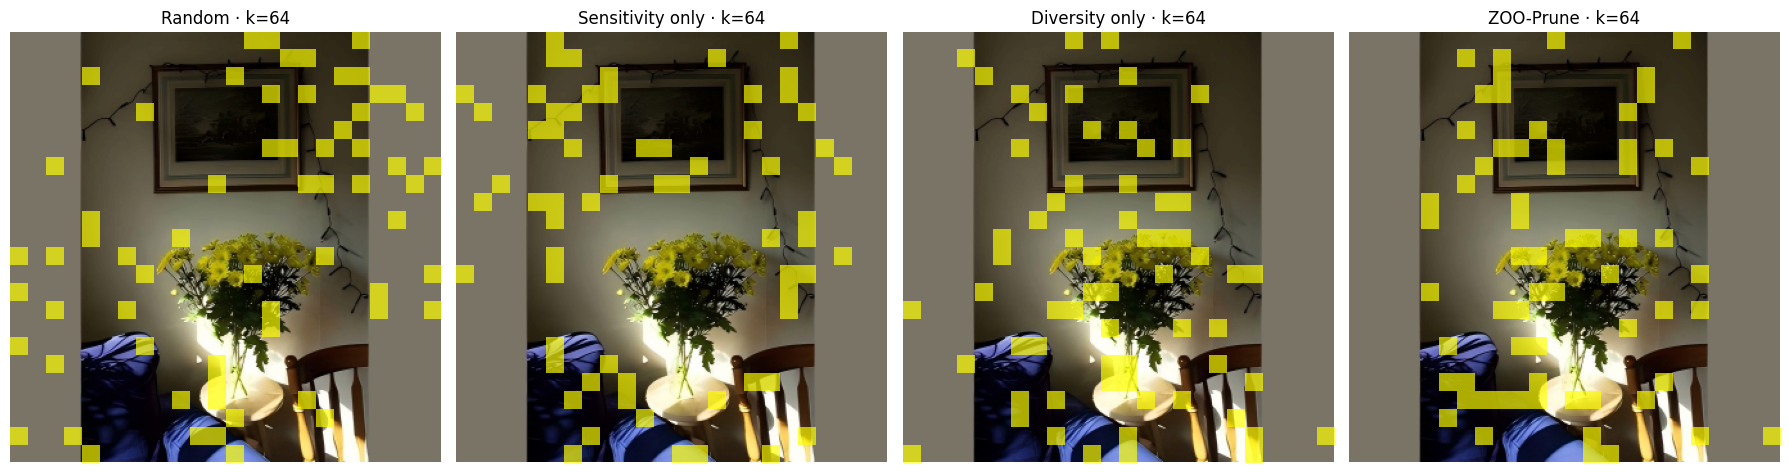

,Strategy,Mean normalized sensitivity ↑,Feature-space coverage ↑
0,Random,0.08,0.88
1,Diversity only,0.09,0.91
2,Sensitivity only,0.15,0.79
3,ZOO-Prune,0.11,0.90


In [ ]:
@torch.no_grad()
def select_diversity_only(features, k):
    """
    Greedy diversity-only selection based on cosine distance.
    Max–Min Diversity Problem (MMDP)
    """

    # Pairwise cosine distance: [N, N]
    features = F.normalize(features.float(),dim=-1,)
    distance = 1 - features @ features.T

    # initialize the selected matrx
    selected = torch.empty(k,dtype=torch.long,device=features.device,)

    for step in range(k):
        if step == 0:
            # Use nearest-neighbor distance as the initial diversity score.
            score = torch.topk(
                distance,
                k=2,
                dim=0,
                largest=False,
            ).values[1]

        else:
             # Maximize distance to the nearest selected token.
            score = distance[
                selected[:step]
            ].min(dim=0).values

            # Prevent duplicate selection.
            score[selected[:step]] = -torch.inf

        selected[step] = score.argmax()

    return selected


def draw_selection(ax, img, indices, title, grid=24):
    """Highlight retained patch tokens """
    mask = np.zeros((grid, grid), dtype=float)
    idx = np.asarray(indices, dtype=int)
    mask[idx // grid, idx % grid] = 1
    ax.imshow(img.resize((336, 336)))
    ax.imshow(mask, cmap="autumn", alpha=np.where(mask > 0, .68, 0), extent=(0, 336, 336, 0), interpolation="nearest")
    ax.set_title(title); ax.axis("off")

# Build four subsets under exactly the same token budget.
g = torch.Generator().manual_seed(SEED)
random_idx = torch.randperm(len(sensitivity), generator=g)[:TOKEN_BUDGET]
sensitivity_idx = sensitivity.topk(TOKEN_BUDGET).indices
diversity_idx = select_diversity_only(projected_tokens.detach(), TOKEN_BUDGET).cpu()
selection_sets = {
    "Random": random_idx,
    "Diversity only": diversity_idx,
    "Sensitivity only": sensitivity_idx,
    "ZOO-Prune": selected_sads,
}


fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, idx, title in zip(axes, [random_idx, sensitivity_idx, diversity_idx, selected_sads],
                          ["Random", "Sensitivity only", "Diversity only", "ZOO-Prune"]):
    draw_selection(ax, presenter_image, idx, f"{title} · k={TOKEN_BUDGET}")
plt.tight_layout(); plt.show()



def selection_diagnostics(features,sensitivity_scores,selections,):
    """
    Measure two complementary properties:

    1. Influence:
       Mean normalized sensitivity of the selected tokens.

    2. Coverage:
       How well the selected subset represents all original
       visual tokens in the projected feature space.
    """
    features = F.normalize(features.detach().float().cpu(),dim=-1,)
    sensitivity_scores = sensitivity_scores.detach().float().cpu()
    normalized_sensitivity = (sensitivity_scores - sensitivity_scores.min()) / (
         sensitivity_scores.max()- sensitivity_scores.min() + 1e-8)
    rows = []
    for name, indices in selections.items():
        indices = indices.long().cpu()
        selected_features = features[indices]

        # ----------------------------------------------------
        # Influence:
        # Higher means that the selected tokens have stronger
        # ZO sensitivity on average.
        # ----------------------------------------------------
        mean_sensitivity = normalized_sensitivity[indices].mean().item()

        # ----------------------------------------------------
        # Feature-space coverage:
        #
        # For each original token, find its most similar selected token.
        # Averaging these best-match similarities measures
        # how well the selected subset represents the complete visual-token set.
        #
        # Shape:
        #   all_to_selected_similarity: [N_v, K]
        # ----------------------------------------------------
        all_to_selected_similarity = (features @ selected_features.T)

        best_match_similarity = (all_to_selected_similarity.max(dim=1).values)

        feature_coverage = (best_match_similarity.mean().item())

        rows.append({
            "Strategy": name,
            "Mean normalized sensitivity ↑": mean_sensitivity,
            "Feature-space coverage ↑": feature_coverage,
        })

    return pd.DataFrame(rows)


display(selection_diagnostics(
        projected_tokens,
        sensitivity,
        selection_sets,
    ).round(2)
)

The four strategies reveal a clear trade-off between **token influence** and **feature-space coverage**:

* **Random**: provides no guarantee of influence or coverage. It serves only as a *lower-bound selection strategy*.

* **Diversity only**: achieves the *highest feature-space coverage* (0.91) by selecting tokens that broadly represent the image. Nevertheless, its *relatively low sensitivity* (0.09) indicates that broad coverage alone does not guarantee that the selected tokens are important for the vision-language mapping.

* **Sensitivity only**: obtains the *highest mean sensitivity* (0.15), showing that it retains the most influential individual tokens. However, its substantially *lower coverage* (0.78) suggests that many selected tokens represent similar visual content and fail to cover the full set of visual features.

* **ZOO-Prune** maintains *both relatively high sensitivity (0.10) and near-best coverage* (0.90). It preserves influential evidence while avoiding excessive concentration on redundant regions.

The desirable subset is therefore not the one that maximizes either metric independently. Instead, `ZOO-Prune seeks a balanced selection that retains influential tokens while sufficiently covering the original visual-token representation.`

# 4. More qualitative and quantitative results
## 4.1 Results across Different VLM Backbones

We compare ZOO-Prune with the corresponding unpruned baseline across different VLM backbones and pruning budgets.


In [ ]:
# @title
import pandas as pd
from IPython.display import display

data = [
    ["LLaVA-1.5-7B",  576,  576,  "0.0%",  "Baseline",  "100.0%"],
    ["LLaVA-1.5-7B",  576,  192,  "66.7%", "ZOO-Prune", "98.27%"],
    ["LLaVA-1.5-7B",  576,  128,  "77.8%", "ZOO-Prune", "97.62%"],
    ["LLaVA-1.5-7B",  576,   64,  "88.9%", "ZOO-Prune", "95.20%"],

    ["LLaVA-1.5-13B", 576,  576,  "0.0%",  "Baseline",  "100.0%"],
    ["LLaVA-1.5-13B", 576,  192,  "66.7%", "ZOO-Prune", "98.6%"],
    ["LLaVA-1.5-13B", 576,  128,  "77.8%", "ZOO-Prune", "97.8%"],
    ["LLaVA-1.5-13B", 576,   64,  "88.9%", "ZOO-Prune", "96.5%"],

    ["LLaVA-NeXT-7B", 2880, 2880, "0.0%",  "Baseline",  "100.0%"],
    ["LLaVA-NeXT-7B", 2880,  640, "77.8%", "ZOO-Prune", "98.3%"],
    ["LLaVA-NeXT-7B", 2880,  320, "88.9%", "ZOO-Prune", "97.1%"],
    ["LLaVA-NeXT-7B", 2880,  160, "94.4%", "ZOO-Prune", "95.4%"],

    ["Qwen2.5-VL-7B", "Dynamic", "100%", "0.0%",  "Baseline",  "100.0%"],
    ["Qwen2.5-VL-7B", "Dynamic",  "20%", "80.0%", "ZOO-Prune", "96.2%"],
    ["Qwen2.5-VL-7B", "Dynamic",  "10%", "90.0%", "ZOO-Prune", "90.8%"],
]

columns = [
    "VLM Backbone", "Original Visual Tokens", "Retained Tokens", "Pruning Ratio",
    "Method", "Relative Performance",]

df = pd.DataFrame(data, columns=columns)

def highlight_baseline(row):
    """Highlight only the unpruned baseline rows."""
    if row["Method"] == "Baseline":
        return ["background-color: #eeeeee"] * len(row)
    return ["background-color: white"] * len(row)


def bold_performance(value):
    return "font-weight: bold"

styled_table = (df.style.apply(highlight_baseline, axis=1).map(
        bold_performance,subset=pd.IndexSlice[df["Method"] == "ZOO-Prune",["Relative Performance"],],)
    .set_properties(**{
        "text-align": "center","padding": "8px","border": "1px solid #cccccc","color": "black",})
    .set_table_styles([
        {"selector": "th","props": [("text-align", "center"),("font-weight", "bold"),("padding", "8px"),
                ("border", "1px solid #cccccc"),],
        },{"selector": "table","props": [("border-collapse", "collapse"),("width", "100%"),],},]).hide(axis="index"))

display(styled_table)

VLM Backbone,Original Visual Tokens,Retained Tokens,Pruning Ratio,Method,Relative Performance
LLaVA-1.5-7B,576,576,0.0%,Baseline,100.0%
LLaVA-1.5-7B,576,192,66.7%,ZOO-Prune,98.27%
LLaVA-1.5-7B,576,128,77.8%,ZOO-Prune,97.62%
LLaVA-1.5-7B,576,64,88.9%,ZOO-Prune,95.20%
LLaVA-1.5-13B,576,576,0.0%,Baseline,100.0%
LLaVA-1.5-13B,576,192,66.7%,ZOO-Prune,98.6%
LLaVA-1.5-13B,576,128,77.8%,ZOO-Prune,97.8%
LLaVA-1.5-13B,576,64,88.9%,ZOO-Prune,96.5%
LLaVA-NeXT-7B,2880,2880,0.0%,Baseline,100.0%
LLaVA-NeXT-7B,2880,640,77.8%,ZOO-Prune,98.3%




### Key observations

- On **LLaVA-1.5-7B**, ZOO-Prune preserves **98.27%**, **97.62%**, and **95.20%** of baseline performance while retaining 192, 128, and 64 visual tokens, respectively.
- On the larger **LLaVA-1.5-13B**, performance remains slightly more robust, reaching **98.6%**, **97.8%**, and **96.5%** at the same token budgets.
- On **LLaVA-NeXT-7B**, ZOO-Prune retains **98.3%**, **97.1%**, and **95.4%** of baseline performance while pruning up to **94.4%** of the original 2,880 visual tokens.

**Takeaway:** ZOO-Prune consistently preserves strong performance across different model capacities, visual-token lengths, and pruning ratios, including highly aggressive compression settings.

## 4.2 Sensitivity vs. Attention vs. Diversity

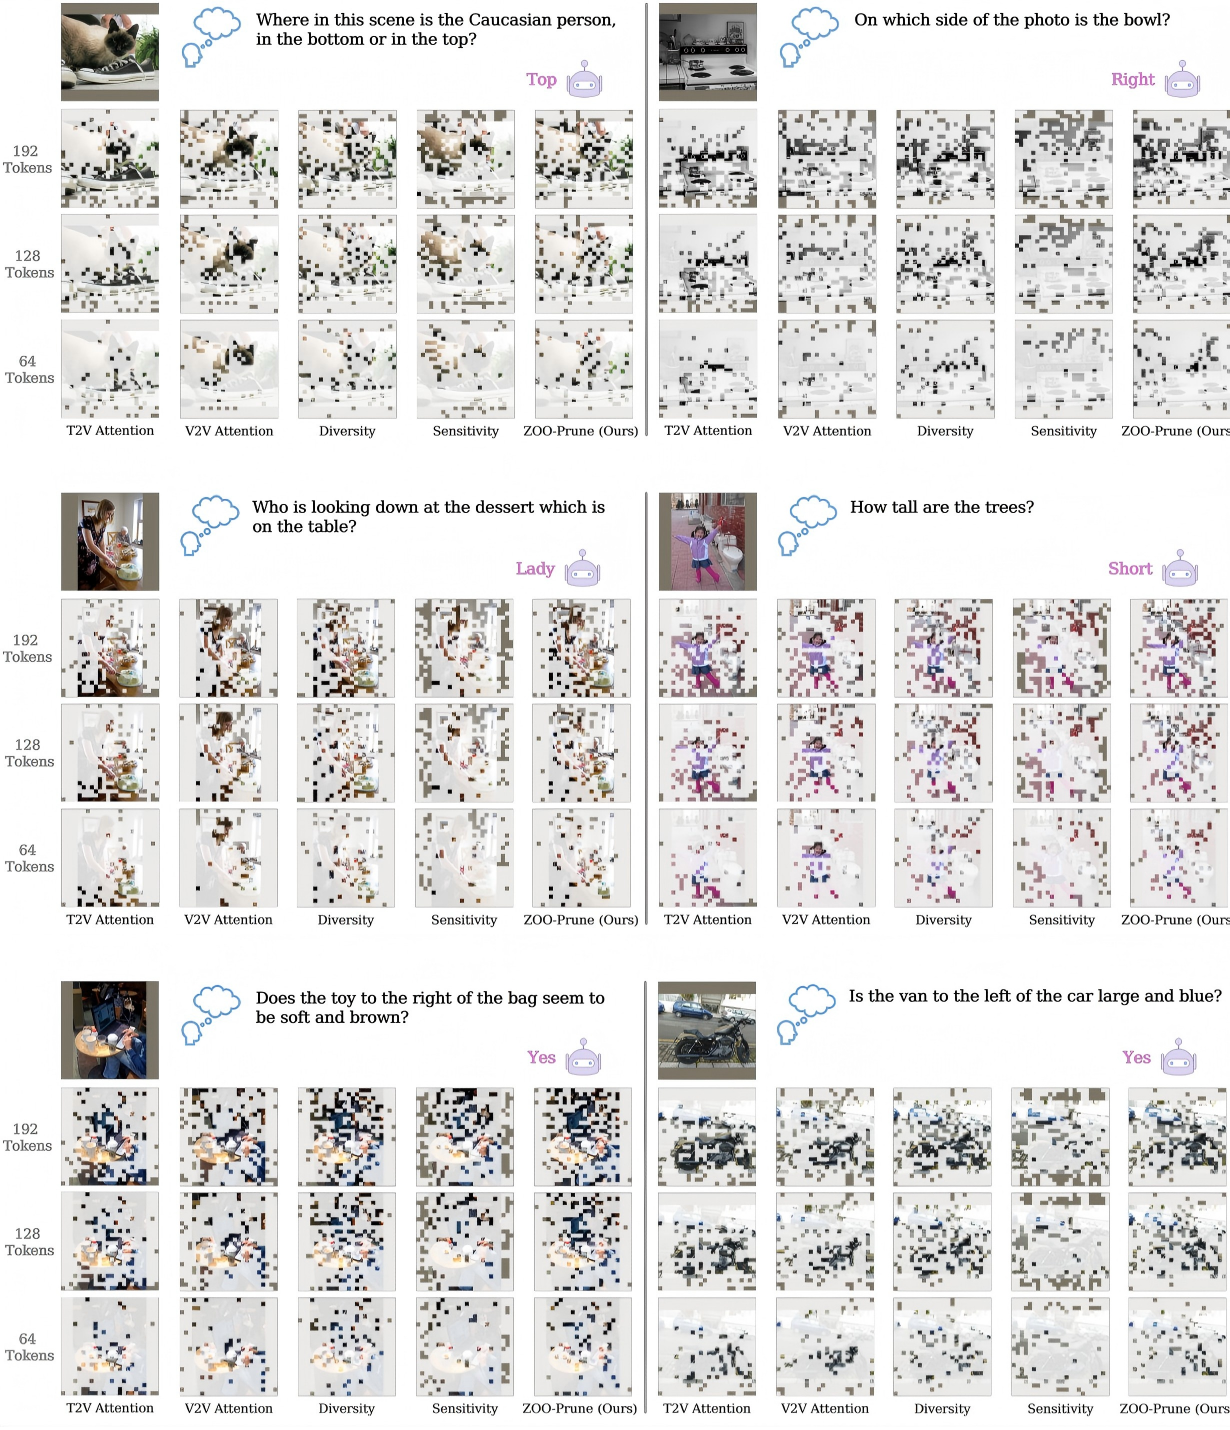

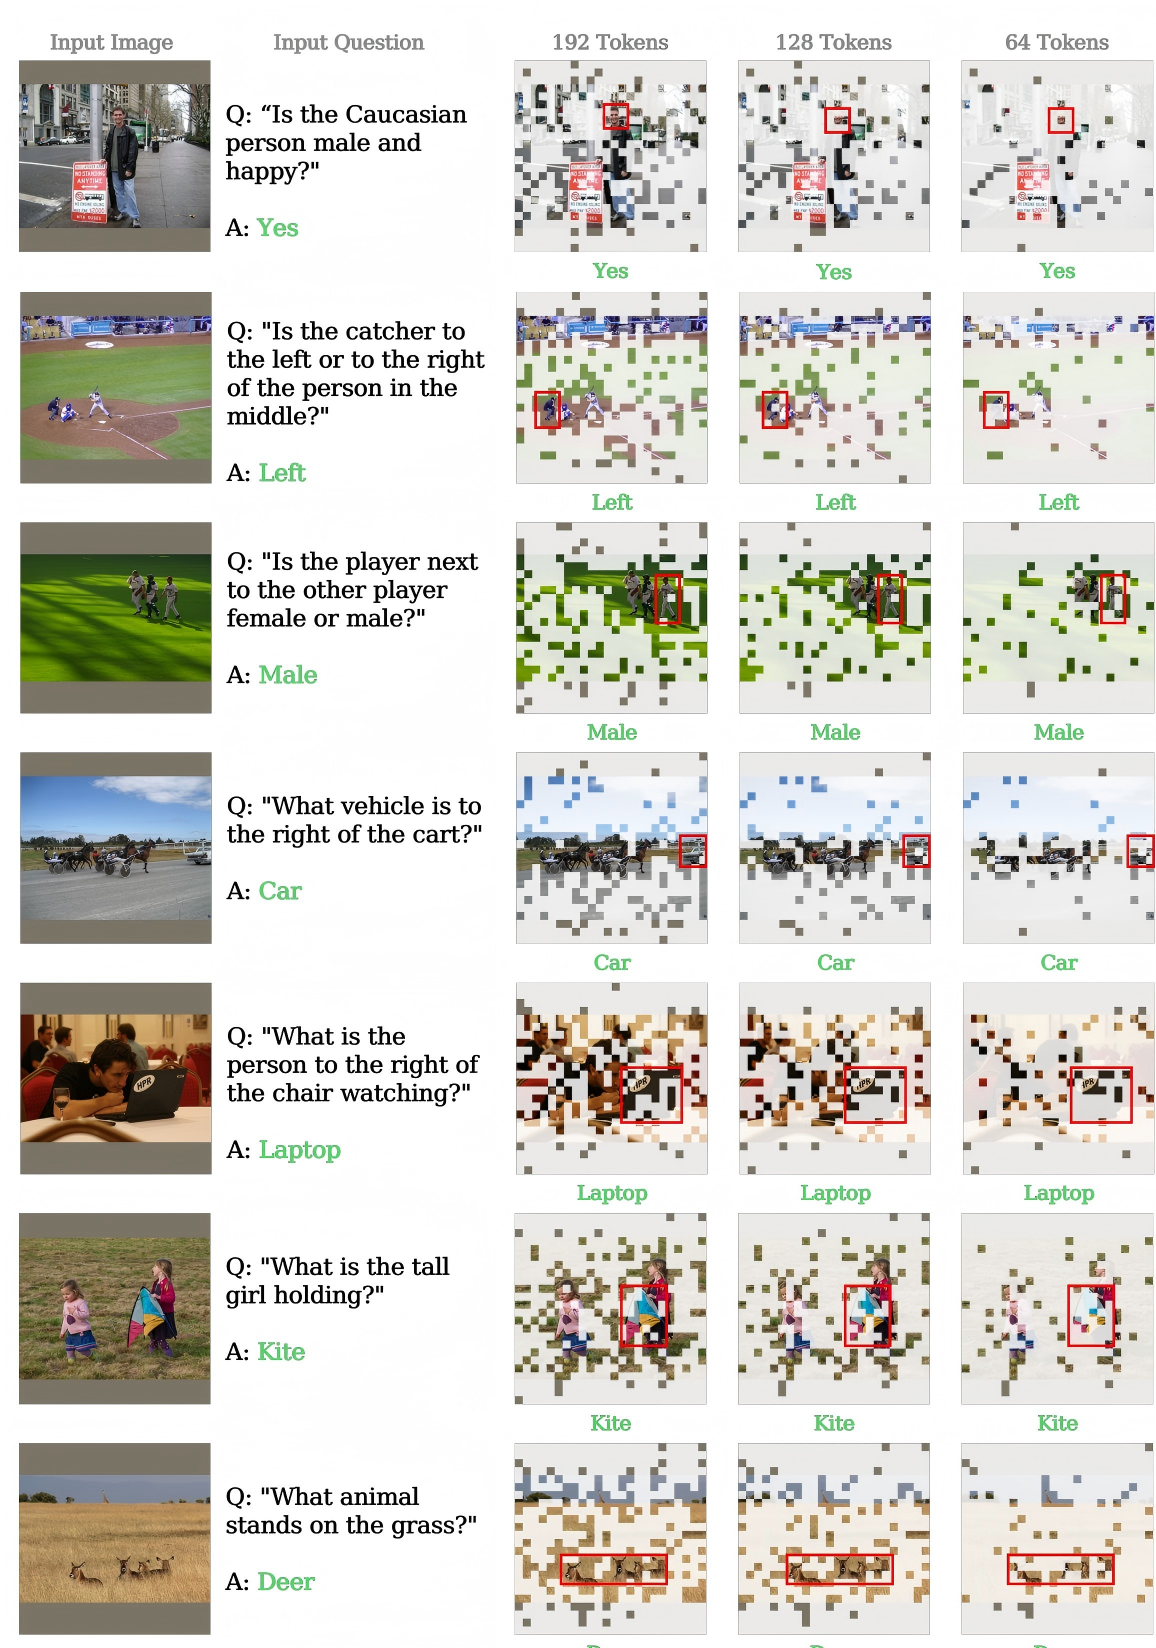

# 5. Further analysis of the sensitivity proxy

* Revisiting Token Sensitivity Proxy: Projector vs. Encoder
* Perturbation stability


## 5.1 Revisiting token sensitivity proxy: Projector vs. Encoder

ZOO-Prune estimates token sensitivity at the multimodal projector, which serves as the interface between the vision encoder and the language model.

A useful ablation compares sensitivity measured:`Visual Sensitivity: Projector vs. Encoder`

*  Compared with the raw encoder response, the projector response provides a more reliable proxy for zeroth-order token sensitivity because it reflects the visual representation actually consumed by the language model.

**Takeaway:** The multimodal projector is a more effective and downstream-relevant location for ZO-based sensitivity estimation.

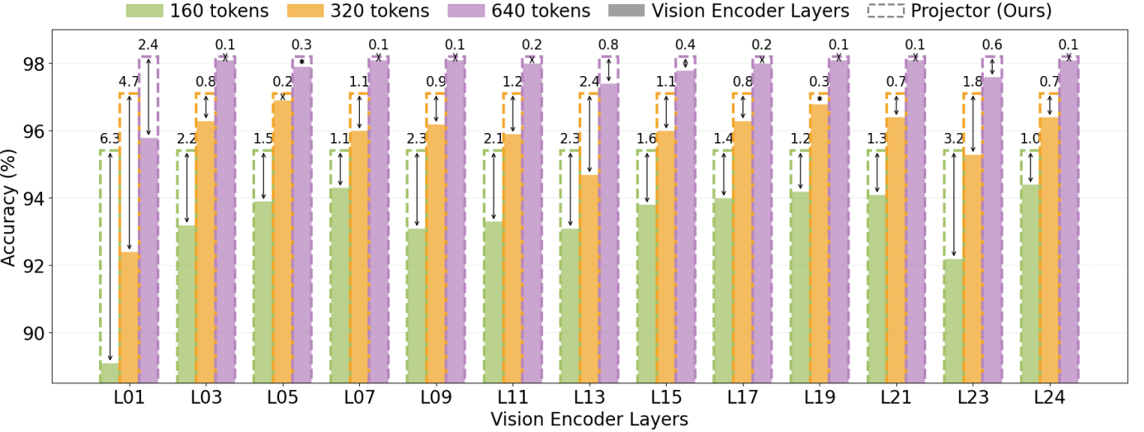

## 5.2 Stability with fewer perturbation directions

The official setting uses $m=64$ random directions.
The experiment below measures *Spearman rank correlation* between a varying-$m$ sensitivity ranking and the 64-direction reference.
- High rank correlations indicate that the sensitivity ranking remains
stable even with fewer perturbation directions.

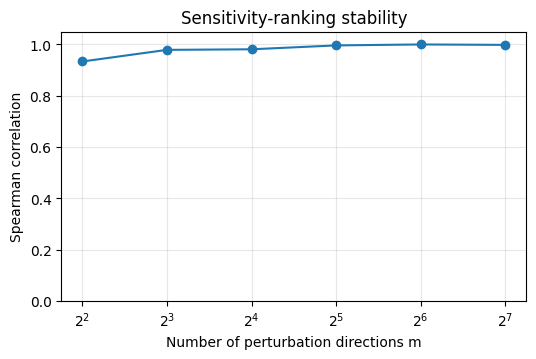

[(4, np.float64(0.9336610839048143)), (8, np.float64(0.9789219074370238)), (16, np.float64(0.9811667373558174)), (32, np.float64(0.9962810241842032)), (64, np.float64(0.9999999999999998)), (128, np.float64(0.9983412883024471))]


In [ ]:
# Compare rankings obtained with fewer perturbation directions
from scipy.stats import spearmanr
stability = []
for m in [4, 8, 16, 32, 64,128]:
    s_m = compute_zoo_sensitivity(pre_projector_tokens, core_model.mm_projector, m=m, h=STEP_SIZE, seed=SEED).float().cpu()
    stability.append((m, spearmanr(sensitivity.numpy(), s_m.numpy()).statistic))

plt.figure(figsize=(6, 3.5))
plt.plot([x[0] for x in stability], [x[1] for x in stability], marker="o")
plt.xscale("log", base=2); plt.ylim(0.0, 1.05)
plt.xlabel("Number of perturbation directions m"); plt.ylabel("Spearman correlation")
plt.title("Sensitivity-ranking stability"); plt.grid(alpha=.3); plt.show()
print(stability)

# 6. Further Inference Efficiency Analysis

## 6.1 Estimated Prefill FLOPs of ZOO-Prune

Let:

- $L$: number of LLM layers
- $N_v$: number of visual tokens before the projector
- $\hat{n}$: total sequence length after pruning
- $d$: LLM hidden dimension
- $d_{\mathrm{ff}}$: LLM feed-forward intermediate dimension.
- $d_v$: vision-feature dimension
- $m$: number of perturbation directions
- $r$: low-rank projector dimension

The total computational cost can be expressed as:

$$
\boxed{
\mathrm{FLOPs}_{\mathrm{total}}
=\mathrm{FLOPs}_{\mathrm{LLM}}(\hat{n}) +\Delta \mathrm{FLOPs}_{\mathrm{ZOO}}
}
$$


Because ZOO-Prune removes visual tokens before they enter the LLM, every LLM layer operates on the shorter sequence $\hat{n}$. The LLM prefill computation is approximated as
$$
\mathrm{FLOPs}_{\mathrm{LLM}}
=
L
\left(
4\hat{n}d^2
+
2\hat{n}^2d
+
2\hat{n}dd_\mathrm{ff}
\right).
$$

The ZOO estimator evaluates \(m\) perturbation directions using symmetric perturbations through a low-rank projector with rank \(r\). Its incremental overhead over the baseline projector is

$$
\begin{aligned}
\Delta \mathrm{FLOPs}_{\mathrm{ZOO}}
&=
\mathrm{FLOPs}_{\mathrm{ZOO,LR}}
-
\mathrm{FLOPs}_{\mathrm{proj}}
\\
&=
2mN_v\frac{d}{r}(d_v+d)
-
N_vd_vd
\\
&=
N_vd^2
\\
&\approx
0.3\%\ \text{of the baseline prefill FLOPs}
\end{aligned}
$$

with the ZOO-Prune setting $m = 64, r = 128. It is negligible.

Therefore, the total prefill cost is

$$
\boxed{
\mathrm{FLOPs}_{\mathrm{total}}
=
L
\left(
4\hat{n}d^2
+
2\hat{n}^2d
+
2\hat{n}dd_\mathrm{ff}
\right)
+
N_vd^2
}
$$

The ZOO overhead is incurred only once and scales linearly with $N_v$, while pruning reduces computation across all LLM layers, including the quadratic self-attention term. Therefore, the one-time ZOO cost is typically outweighed by the computation saved in the LLM.



## 6.2 Inference efficiency
*(on the POPE benchmark relative to the LLaVA-NeXT-7B baseline)*

ZOO-Prune offers the most favorable balance between speed and accuracy.
- Reduces FLOPs from 11.8 TFLOPs to **0.9 TFLOPs**
- Achieves **2.59×** faster prefill
- Delivers up to **2.30×** end-to-end speedup

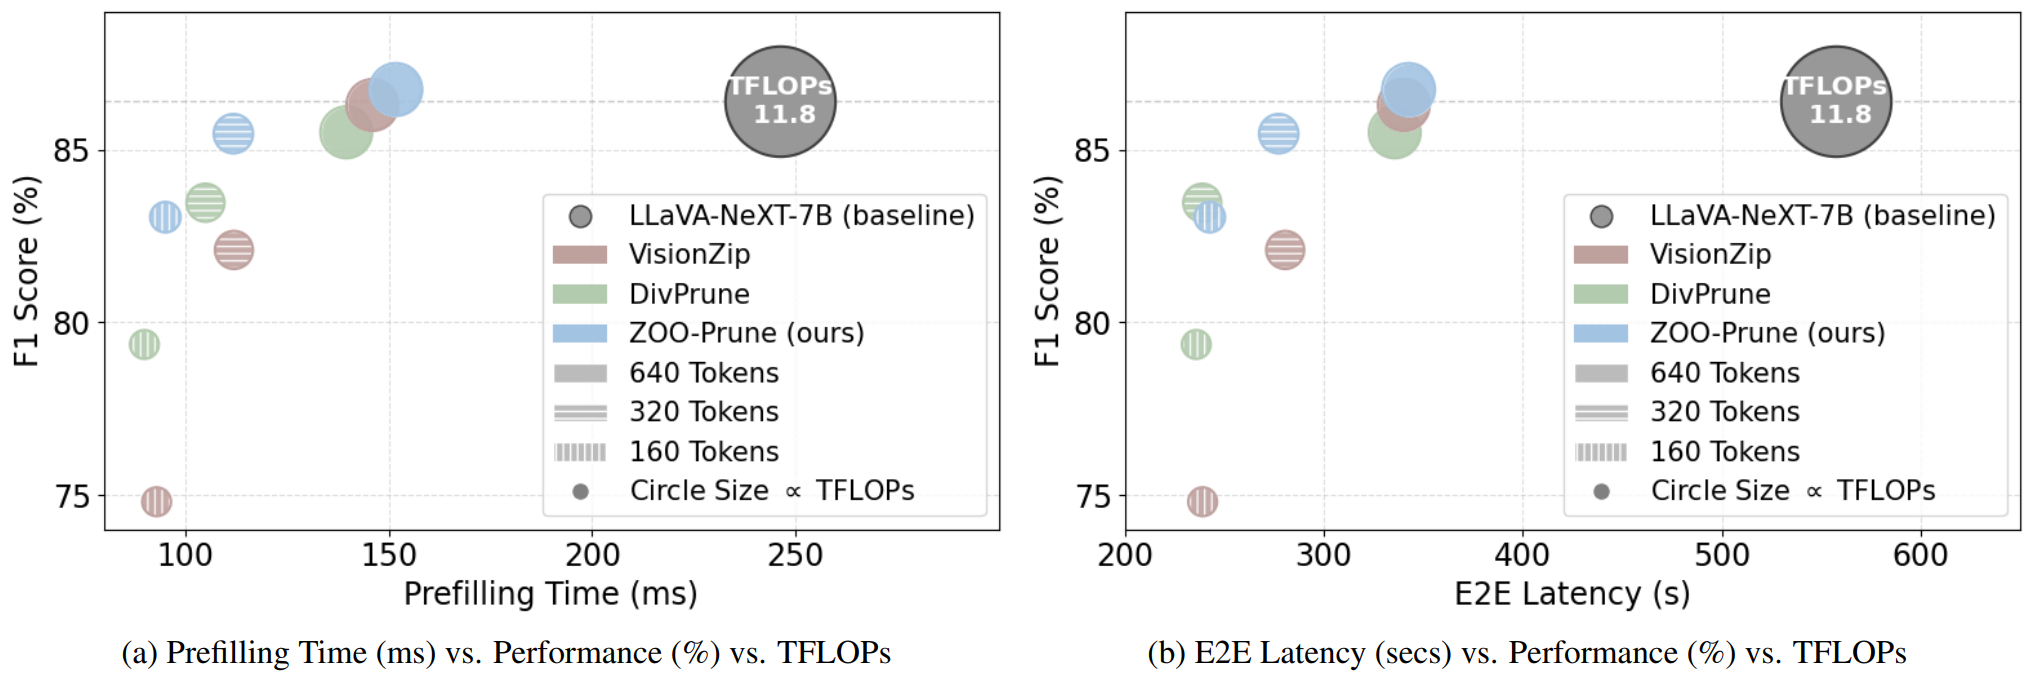

# Takeaways

### 1. Output-Aware Sensitivity Estimation

* Measures token importance through changes in the projected output.
* Requires only forward passes, without backpropagation.
* Identifies visual tokens that strongly influence the vision-language interface.

### 2. Sensitivity-Aware Diversity Selection

* Combines token sensitivity with feature diversity.
* Avoids repeatedly selecting redundant neighboring tokens.
* Preserves both influential evidence and broad visual coverage.

### 3. Efficient Visual Token Pruning

* Prunes visual tokens before they enter the LLM.
* Reduces the visual sequence length and prefill computation.
* Remains effective even under aggressive pruning budgets.

## Final Takeaway

**ZOO-Prune enables `training-free `and `output-aware` visual token pruning by combining efficient zeroth-order sensitivity estimation with diversity-aware token selection.**
